In [1]:
import time
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
train = np.load("./data/processed/dataset_train.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]          # int {0,1}

full = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X_full = full["X"]
K0_full = full["K0"]


In [3]:
def fit_scaler(X_train):
    scaler = StandardScaler()
    return scaler.fit(X_train)

In [4]:
def run_supervised_pipeline(
    model,
    X_train, y_train,
    X_full
):
    # --- preprocessing ---
    scaler = fit_scaler(X_train)
    X_train_scaled = scaler.transform(X_train)

    # --- train ---
    model.fit(X_train_scaled, y_train)

    train_score = model.score(X_train_scaled, y_train)

    # --- classify FULL dataset ---
    X_full_scaled = scaler.transform(X_full)

    if hasattr(model, "predict_proba"):
        P_A = model.predict_proba(X_full_scaled)[:, 1]
    else:
        scores = model.decision_function(X_full_scaled)
        P_A = 1 / (1 + np.exp(-scores))  # sigmoid

    return {
        "model": model,
        "scaler": scaler,
        "train_score": train_score,
        "P_A": P_A
    }


In [5]:
def phase_analysis(P_A, K0_full):
    df = pd.DataFrame({
        "K0": K0_full,
        "P_A": P_A
    })

    grouped = df.groupby("K0")

    mean_P = grouped.mean()["P_A"]
    var_P  = grouped.var()["P_A"]

    return mean_P, var_P

In [6]:
def plot_phase_results(mean_P, var_P, title_prefix=""):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    ax[0].plot(mean_P.index, mean_P.values, "o-")
    ax[0].set_xlabel("K0")
    ax[0].set_ylabel("⟨P(A)⟩")
    ax[0].set_title(f"{title_prefix} Mean probability")

    ax[1].plot(var_P.index, var_P.values, "o-")
    ax[1].set_xlabel("K0")
    ax[1].set_ylabel("Var(P(A))")
    ax[1].set_title(f"{title_prefix} Susceptibility")

    for a in ax:
        a.grid(True)

    plt.show()


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=0),
    "Gradient Boosted Trees": GradientBoostingClassifier(random_state=0),
    "kNN": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500)
}



=== Logistic Regression ===
Train accuracy: 1.0000
Elapsed time: 16.26 s


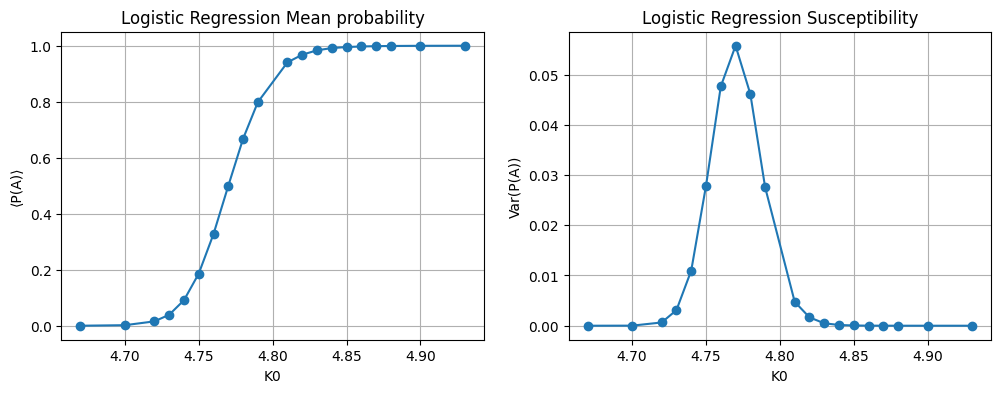


=== Decision Tree ===
Train accuracy: 1.0000
Elapsed time: 28.26 s


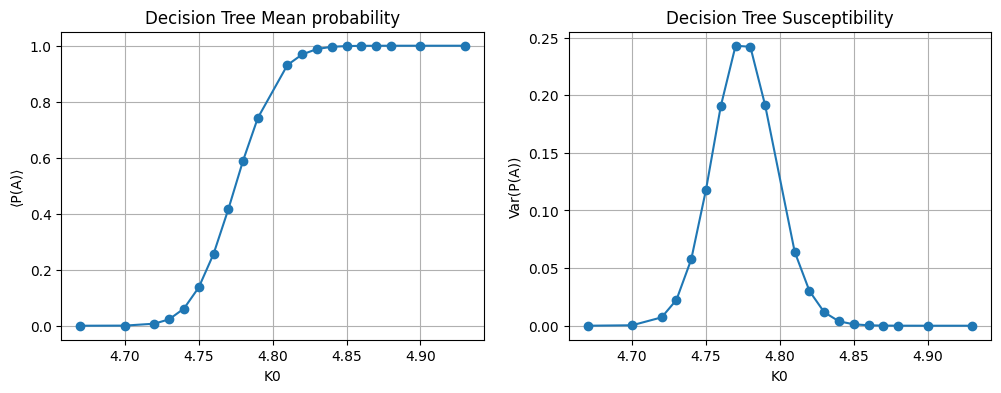


=== Random Forest ===
Train accuracy: 1.0000
Elapsed time: 118.23 s


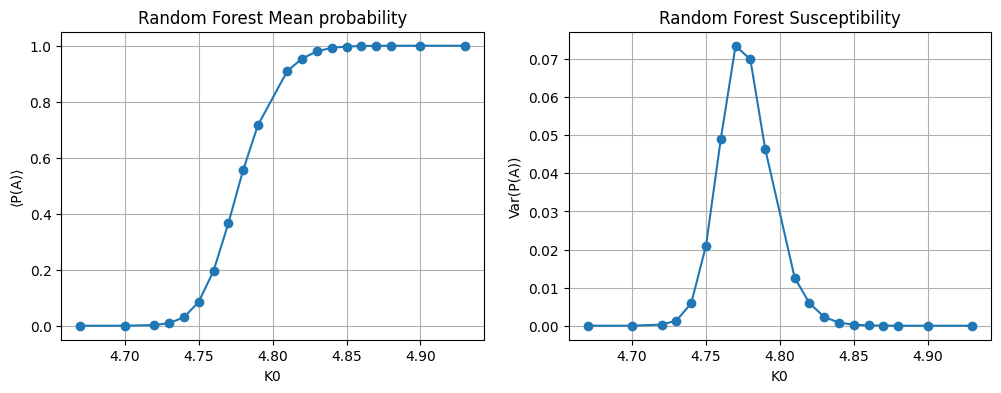


=== Gradient Boosted Trees ===
Train accuracy: 1.0000
Elapsed time: 93.51 s


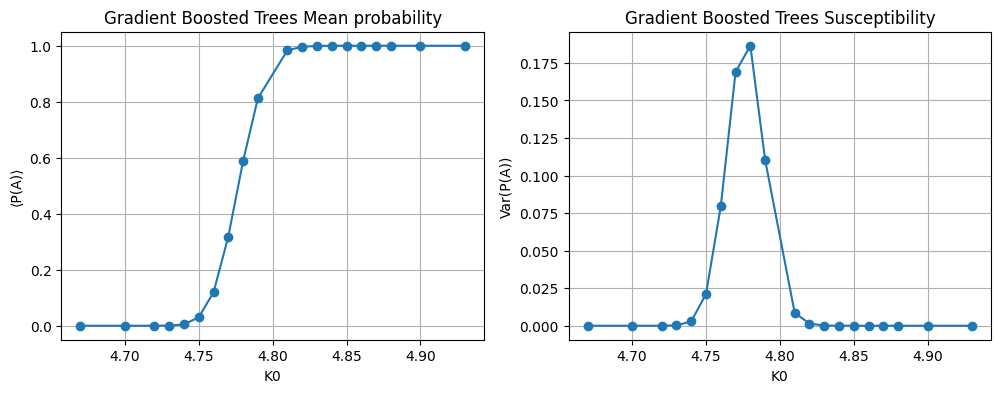


=== kNN ===
Skipping full classification due to computational cost.

=== SVM (RBF) ===
Train accuracy: 1.0000
Elapsed time: 505.89 s


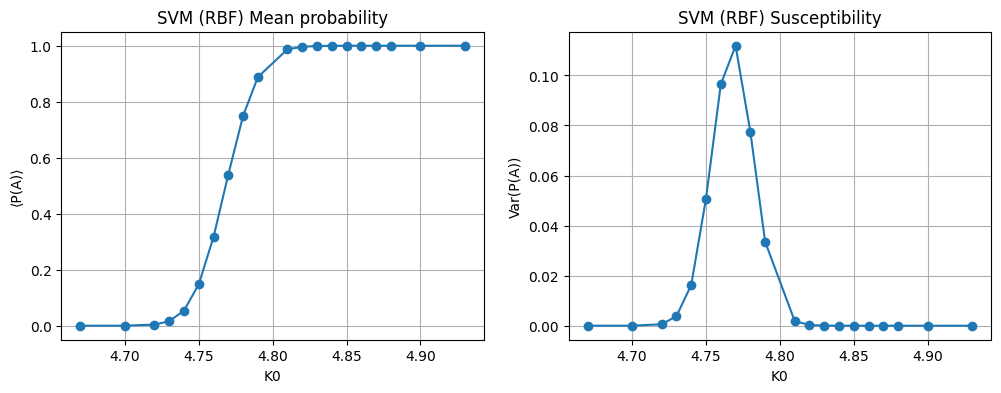


=== Neural Network ===
Skipping Neural Network in main loop (memory intensive).


,train_score,time_sec
Logistic Regression,1.0,16.258058
Decision Tree,1.0,28.256808
Gradient Boosted Trees,1.0,93.512330
Random Forest,1.0,118.229489
SVM (RBF),1.0,505.893460


In [8]:
results = {}

for name, model in models.items():
    print(f"\n=== {name} ===")

    if name == "kNN":
        print("Skipping full classification due to computational cost.")
        continue
    if name == "Neural Network":
        print("Skipping Neural Network in main loop (memory intensive).")
        continue
    t0 = time.perf_counter()

    res = run_supervised_pipeline(
        model,
        X_train, y_train,
        X_full
    )

    t1 = time.perf_counter()
    elapsed = t1 - t0

    mean_P, var_P = phase_analysis(res["P_A"], K0_full)

    print(f"Train accuracy: {res['train_score']:.4f}")
    print(f"Elapsed time: {elapsed:.2f} s")

    plot_phase_results(mean_P, var_P, name)

    results[name] = {
        "mean_P": mean_P,
        "var_P": var_P,
        "train_score": res["train_score"],
        "time_sec": elapsed
    }


summary = pd.DataFrame.from_dict(results, orient="index")
summary = summary[["train_score", "time_sec"]]
summary.sort_values("time_sec")